# Data

In [244]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import copy
from torch.utils.data import TensorDataset, DataLoader

from sklearn.decomposition import PCA

In [245]:
data = np.loadtxt(open('/content/sample_data/mnist_train_small.csv', 'rb'), delimiter = ',')
labels = data[:,0]
data = data[:,1:]
data = torch.tensor(data, dtype = torch.float)
data = data / torch.max(data)
data.shape

torch.Size([20000, 784])

# Model

In [246]:
def CreateNet():
  class AENet(nn.Module):
    def __init__(self):
      super().__init__()

      self.inp = nn.Linear(784, 250)
      self.enc = nn.Linear(250, 15)
      self.lat = nn.Linear(15, 250)
      self.dec = nn.Linear(250, 784)

    def forward(self, x):
      x = F.relu(self.inp(x))
      # we save code_x i.e., latent layer
      code_x = F.relu(self.enc(x))
      x = F.relu(self.lat(code_x))
      x = self.dec(x)
      y = torch.sigmoid(x)
      # we return y, and code_x
      return y, code_x

  net = AENet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [247]:
x = torch.randn(10, 784)
net, loss_fn, optimizer = CreateNet()
y, code_x = net(x)
y.shape, code_x.shape

(torch.Size([10, 784]), torch.Size([10, 15]))

# Train

In [248]:
def ModelTrain(epochs, verbose):
  net, loss_fn, optimizer = CreateNet()

  losses = torch.zeros(epochs)

  for epoch in range(epochs):
    random_idxs = np.random.choice(data.shape[0], 32, replace = False)
    x = data[random_idxs, :]

    # We care just about y
    x_hat = net(x)[0]
    loss = loss_fn(x_hat, x)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses[epoch] = loss.item()

    if verbose and epoch%100 == 0:
      print(f'Epoch: {epoch} | Loss: {losses[epoch]:.2f}')

  return losses, net

In [249]:
losses, net = ModelTrain(epochs = 3000, verbose = True)

Epoch: 0 | Loss: 0.23
Epoch: 100 | Loss: 0.06
Epoch: 200 | Loss: 0.04
Epoch: 300 | Loss: 0.03
Epoch: 400 | Loss: 0.03
Epoch: 500 | Loss: 0.03
Epoch: 600 | Loss: 0.03
Epoch: 700 | Loss: 0.03
Epoch: 800 | Loss: 0.03
Epoch: 900 | Loss: 0.03
Epoch: 1000 | Loss: 0.03
Epoch: 1100 | Loss: 0.02
Epoch: 1200 | Loss: 0.02
Epoch: 1300 | Loss: 0.02
Epoch: 1400 | Loss: 0.02
Epoch: 1500 | Loss: 0.03
Epoch: 1600 | Loss: 0.02
Epoch: 1700 | Loss: 0.03
Epoch: 1800 | Loss: 0.03
Epoch: 1900 | Loss: 0.02
Epoch: 2000 | Loss: 0.02
Epoch: 2100 | Loss: 0.02
Epoch: 2200 | Loss: 0.02
Epoch: 2300 | Loss: 0.02
Epoch: 2400 | Loss: 0.02
Epoch: 2500 | Loss: 0.03
Epoch: 2600 | Loss: 0.03
Epoch: 2700 | Loss: 0.02
Epoch: 2800 | Loss: 0.02
Epoch: 2900 | Loss: 0.02


# Pred

In [250]:
y_hat, latent = net(data)

# Plot

yhat: torch.Size([20000, 784])
latent: torch.Size([20000, 15])


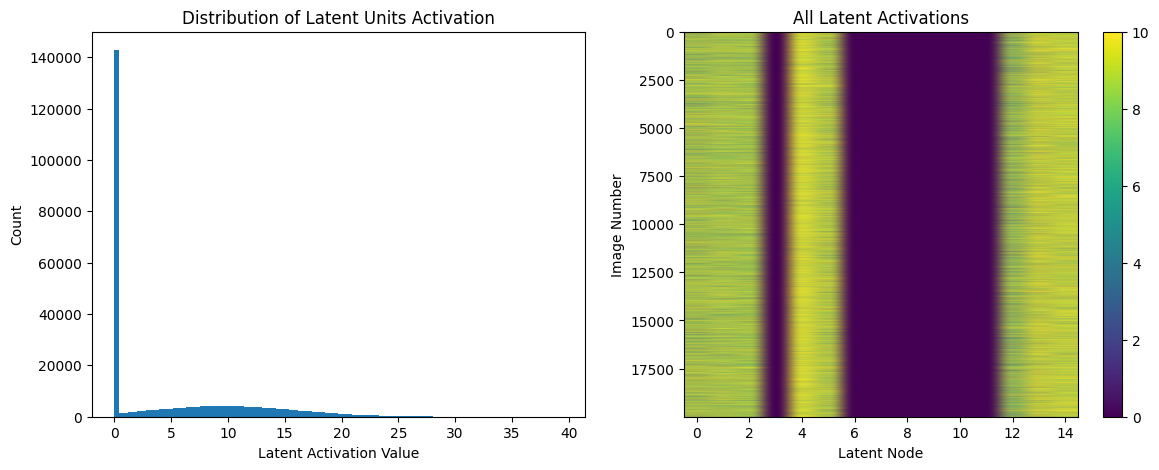

In [251]:
print('yhat:',y_hat.shape)
print('latent:',latent.shape)

fig, ax = plt.subplots(1,2,figsize = (14,5))

ax[0].hist(latent.detach().flatten(), 100)
ax[0].set_xlabel('Latent Activation Value')
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of Latent Units Activation')

ax[1].imshow(latent.detach(), aspect = 'auto', vmin = 0, vmax = 10)
ax[1].set_xlabel('Latent Node')
ax[1].set_ylabel('Image Number')
ax[1].set_title('All Latent Activations')

fig.colorbar(ax[1].images[0], ax=ax[1])
plt.show()

# Internal Representation of Numbers

/tmp/ipython-input-2057429890.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  source_code[:,i] = torch.mean(latent[digit_ids,:], axis = 1).detach()


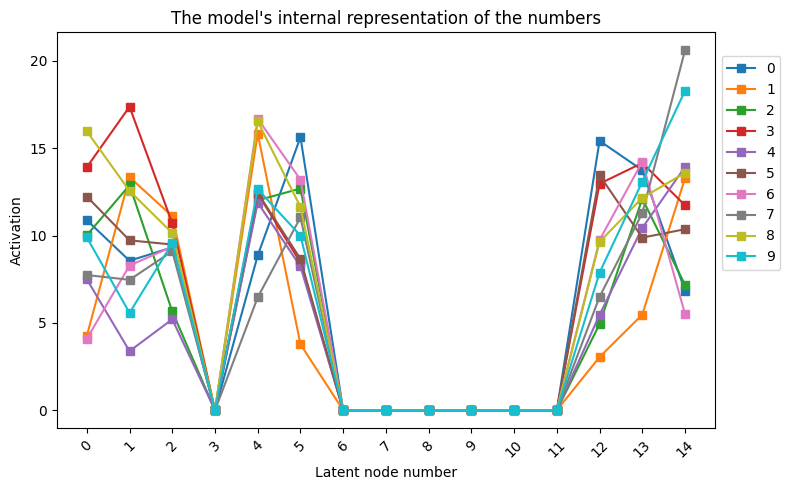

In [252]:
source_code = np.zeros((latent.shape[1], 10))

for i in range(10):
  # find all pictures of this category
  digit_ids = np.where(labels == i)

  # average the latent layer output
  source_code[:,i] = torch.mean(latent[digit_ids,:], axis = 1).detach()

fig = plt.figure(figsize = (8,5))

plt.plot(source_code, 's-')
plt.legend(range(10), loc = (1.01,.4))
plt.xticks(range(latent.shape[1]), rotation=45)
plt.xlabel('Latent node number')
plt.ylabel('Activation')
plt.title('The model\'s internal representation of the numbers')
plt.tight_layout()
plt.show()

We can see that some of the nodes are not fired at all, meaning that they are not used for any class.

# Explore the Reduced-Compressed Space with PCA

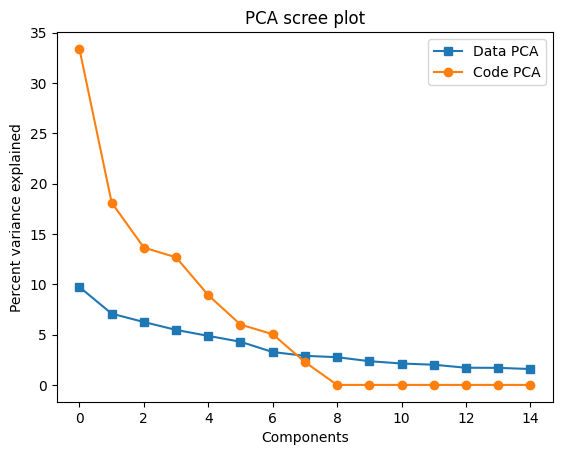

In [253]:
# compute and fit the PCA
pca_data = PCA(n_components=15).fit(data)
pca_code = PCA().fit(latent.detach())

# plot the eigenspectra (screen plot)
plt.plot(100*pca_data.explained_variance_ratio_,'s-',label='Data PCA')
plt.plot(100*pca_code.explained_variance_ratio_,'o-',label='Code PCA')
plt.xlabel('Components')
plt.ylabel('Percent variance explained')
plt.title('PCA scree plot')
plt.legend()
plt.show()

In [254]:
latent.shape[1]

15

Our original latent space has 15 neurons. From scree plot we can tell that's way too much and we should take 5 neurons tops due to percent variance explained decrease. More dimensions don't explain data at all, and are considered as redundant noise. Therefore for this particular data and architecture we should rerun model, but down to 5 neurons of latent space.

# Projection of data onto PC axes

Text(0.5, 1.0, 'PCA of latent space')

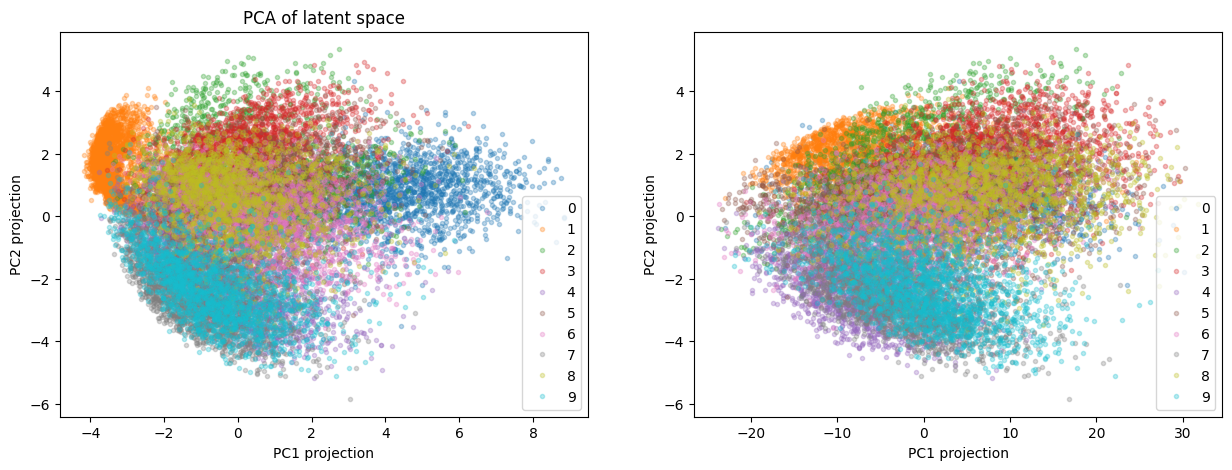

In [255]:
scores_data = pca_data.fit_transform(data)
scores_code = pca_code.fit_transform(latent.detach())

# plot the data separately per number
fig, ax = plt.subplots(1,2,figsize = (15,5))

for lab in range(10):
  ax[0].plot(scores_data[labels==lab,0], scores_data[labels==lab,1], 'o', markersize=3, alpha = .3)
  ax[1].plot(scores_code[labels==lab,0], scores_data[labels==lab,1], 'o', markersize=3, alpha=.3)

for i in range(2):
  ax[i].set_xlabel('PC1 projection')
  ax[i].set_ylabel('PC2 projection')
  ax[i].legend(range(10))

ax[0].set_title('PCA of data')
ax[0].set_title('PCA of latent space')

# Check latent layer

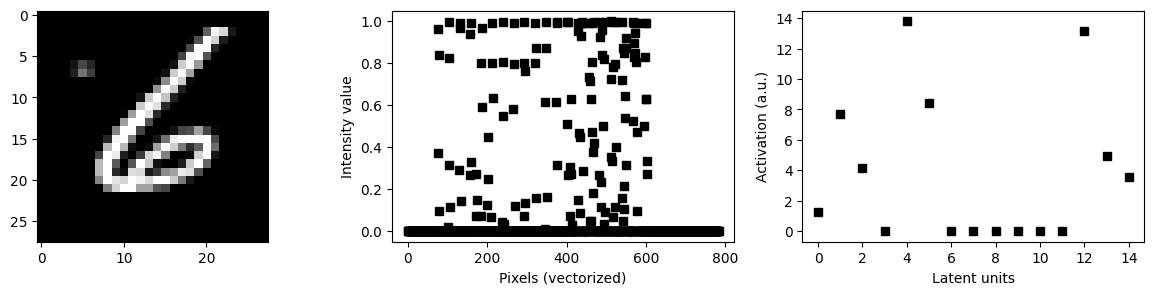

In [256]:
fig, ax = plt.subplots(1,3,figsize=(15,3))

rand_row = np.random.randint(data.shape[0])

ax[0].imshow(data[rand_row,:].view(28,28), cmap = 'gray')

ax[1].plot(data[rand_row,:], 'ks')
ax[1].set_xlabel('Pixels (vectorized)')
ax[1].set_ylabel('Intensity value')

ax[2].plot(latent[rand_row,:].detach(), 'ks')
ax[2].set_xlabel('Latent units')
ax[2].set_ylabel('Activation (a.u.)')

plt.show()

# Conclusion

Even though we explored the latent layer, we did it for this certain model. New run would return different results, thats why scree plot in Autoencoder is useless, it's not stable. We just get an insight to the current model latent layer, but if we rerun model we will get different latent layer. That's why we shouldn't use scree plot in AE.